# Очистка данных

Отдельный ноутбук для подготовки `clean_df` на основе `dataset.xlsx` и `regions_extended.csv`.

Цель:
- сформировать воспроизводимый пайплайн очистки;
- убрать технические дубли и очевидно некорректные записи;
- отдельно удалить водительские резюме без водительских прав;
- получить чистый датафрейм для последующего анализа.

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

## 1. Загрузка данных

In [50]:
raw_df = pd.read_excel("dataset.xlsx")
regions = pd.read_csv("regions_extended.csv", dtype={"code": str})

print("raw_df shape:", raw_df.shape)
print("regions shape:", regions.shape)
raw_df.head(3)

raw_df shape: (49999, 54)
regions shape: (89, 3)


,add_certificates,additional_skills,birthday,birthday_mistake,business_trips,busy_type,country,date_creation,date_inactivation,date_last_updated,date_modify_inner_info,date_publish,date_time_publish,drive_licences,driver_licence_a,driver_licence_b,driver_licence_c,driver_licence_d,driver_licence_e,education_type,experience,experience_mistake,gender,id_candidate,id_cv,id_user_inner_info,inactive,industry_code,inner_info_fullness_rate,inner_info_status,locality,nark_certificate,other_info,position_name,profession_code,region_code,relocation,retraining_capability,salary,schedule_type,schedule_type_1,schedule_type_2,schedule_type_3,schedule_type_4,schedule_type_5,schedule_type_6,skills,time_publish,worldskills_international_name,worldskills_is_international,worldskills_russian_name,worldskills_skill_abbreviation,worldskills_type,worldskills_inspection_status
0,NaN,"Коммуникабельность, дипломатичность, ответстве...",NaN,NaN,0.0,Полная занятость,Российская Федерация,2018-02-12,2019-02-18,2018-10-25,2018-02-12,2018-02-12,2018-02-12 16:48:18,NaN,0,0,0,0,0,NaN,4.0,0,NaN,71a19a60-0fdf-11e8-860a-ef76bd2a03c1,b2ac2f0e-0feb-11e8-860a-ef76bd2a03c1,6c440150-1ea6-11e7-8b66-5d9e90ab9534,1,DeskWork,91,Одобрено,2.300000e+12,NaN,Трудовая деятельность началась с должности сек...,"Делопроизводитель, офис-менеджер, администратор",NaN,2.300000e+12,0.0,1.0,25000,Полный рабочий день,0,0,0,0,1,0,"Офисные программы Li e Office, Word, Excel. 1 ...",16:48:18,NaN,NaN,NaN,NaN,NaN,Не применимо
1,NaN,"Честность, обучаемость, любознательность, акку...",NaN,NaN,0.0,Полная занятость,Российская Федерация,2018-03-29,2019-02-18,2018-12-22,2018-12-19,2018-12-19,2018-12-19 15:38:35,NaN,0,0,0,0,0,NaN,11.0,0,NaN,53ff77c0-a289-11e7-ac45-736ab11edb0c,1d89b050-333b-11e8-b81f-736ab11edb0c,d07779a0-1e61-11e5-8442-1ff705945672,1,DeskWork,92,Одобрено,3.600000e+12,NaN,NaN,Оператор 1с,NaN,3.600000e+12,0.0,1.0,15000,Полный рабочий день,0,0,0,0,1,0,Правильное распределение и хранение документов...,15:38:35,NaN,NaN,NaN,NaN,NaN,Не применимо
2,NaN,"Дисциплинирована, пунктуальна, внимательна, от...",NaN,NaN,0.0,Полная занятость,Российская Федерация,2017-11-20,2019-02-18,2018-01-02,2017-11-21,2017-11-21,2017-11-21 06:49:18,NaN,0,0,0,0,0,NaN,0.0,0,NaN,629bcf80-cde6-11e7-bf93-037acc02728d,06e28f24-cde7-11e7-a533-9122a281f90e,a69177d0-218f-11e6-a9d7-5d9e90ab9534,1,Marketing,76,Одобрено,7.200000e+12,NaN,NaN,"Социолог , маркетолог, аналитик",265312.0,7.200000e+12,0.0,1.0,25000,"Полный рабочий день,Сменный график",0,0,0,0,1,1,Способность использовать знание методов и теор...,06:49:18,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Базовый профиль сырого датасета

In [51]:
raw_summary = {
    "rows": len(raw_df),
    "columns": raw_df.shape[1],
    "full_row_duplicates": int(raw_df.duplicated().sum()),
    "duplicated_id_cv": int(raw_df["id_cv"].duplicated().sum()),
    "duplicated_id_candidate": int(raw_df["id_candidate"].duplicated().sum()),
}
raw_summary

{'rows': 49999,
 'columns': 54,
 'full_row_duplicates': 0,
 'duplicated_id_cv': 4251,
 'duplicated_id_candidate': 8065}

In [52]:
(raw_df.isna().mean() * 100).sort_values(ascending=False).head(15).round(2)

worldskills_international_name    99.92
worldskills_skill_abbreviation    99.88
worldskills_russian_name          99.88
worldskills_is_international      99.88
nark_certificate                  99.81
worldskills_type                  99.78
add_certificates                  92.24
other_info                        85.89
education_type                    81.02
birthday                          76.75
birthday_mistake                  75.33
drive_licences                    63.86
profession_code                   52.83
skills                            50.32
additional_skills                 37.22
dtype: float64

## 3. Правила очистки

В этом ноутбуке используются следующие правила:

1. Удаляются полные дубли строк.
2. Для повторяющихся `id_cv` сохраняется последняя версия резюме по доступным датам.
3. Зарплата должна попадать в диапазон от МРОТ на дату публикации резюме до `400000` рублей.
4. Опыт работы должен быть неотрицательным и не должен быть пропущен.
5. Если позиция относится к водительским, но ни одной категории водительских прав нет, запись удаляется.
6. Добавляются расшифровки регионов, теги регионов из `regions_extended.csv` и федеральный округ.

Важно: это не максимально агрессивная очистка. Пропуски по возрасту, образованию и текстовым полям не удаляются автоматически, чтобы не потерять большую часть выборки.

## 4. Подготовка типов и служебных признаков

In [53]:
df = raw_df.copy()

date_cols = [
    "date_creation",
    "date_inactivation",
    "date_last_updated",
    "date_modify_inner_info",
    "date_publish",
    "date_time_publish",
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

numeric_cols = [
    "salary",
    "experience",
    "birthday",
    "inner_info_fullness_rate",
    "relocation",
    "business_trips",
    "retraining_capability",
    "driver_licence_a",
    "driver_licence_b",
    "driver_licence_c",
    "driver_licence_d",
    "driver_licence_e",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["position_name_norm"] = (
    df["position_name"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

licence_cols = [
    "driver_licence_a",
    "driver_licence_b",
    "driver_licence_c",
    "driver_licence_d",
    "driver_licence_e",
]

df["has_any_driver_licence"] = df[licence_cols].fillna(0).max(axis=1).eq(1)
df["is_driver_role"] = df["position_name_norm"].str.contains(r"(?:^|\W)водител", regex=True)

mrot_schedule = [
    (pd.Timestamp("2016-01-01"), 6204),
    (pd.Timestamp("2016-07-01"), 7500),
    (pd.Timestamp("2017-01-01"), 7500),
    (pd.Timestamp("2017-07-01"), 7800),
    (pd.Timestamp("2018-01-01"), 9489),
    (pd.Timestamp("2018-05-01"), 11163),
    (pd.Timestamp("2019-01-01"), 11280),
    (pd.Timestamp("2020-01-01"), 12130),
    (pd.Timestamp("2021-01-01"), 12792),
    (pd.Timestamp("2022-01-01"), 13890),
    (pd.Timestamp("2022-06-01"), 15279),
    (pd.Timestamp("2023-01-01"), 16242),
    (pd.Timestamp("2024-01-01"), 19242),
]

df["salary_floor_mrot"] = np.nan
for effective_date, mrot_value in mrot_schedule:
    df.loc[df["date_publish"] >= effective_date, "salary_floor_mrot"] = mrot_value

df["salary_valid"] = (
    df["salary"].notna()
    & df["salary_floor_mrot"].notna()
    & df["salary"].ge(df["salary_floor_mrot"])
    & df["salary"].le(400000)
)
df["experience_valid"] = df["experience"].ge(0) & df["experience"].notna()

df["region_prefix"] = pd.to_numeric(df["region_code"], errors="coerce").astype("Int64").astype("string").str[:2].str.zfill(2)
df = df.merge(regions, left_on="region_prefix", right_on="code", how="left")
df = df.rename(columns={"region": "region_name", "group": "region_group"})

fd_map = {
    "Москва": "Центральный",
    "Московская область": "Центральный",
    "Белгородская область": "Центральный",
    "Брянская область": "Центральный",
    "Владимирская область": "Центральный",
    "Воронежская область": "Центральный",
    "Ивановская область": "Центральный",
    "Калужская область": "Центральный",
    "Костромская область": "Центральный",
    "Курская область": "Центральный",
    "Липецкая область": "Центральный",
    "Орловская область": "Центральный",
    "Рязанская область": "Центральный",
    "Смоленская область": "Центральный",
    "Тамбовская область": "Центральный",
    "Тверская область": "Центральный",
    "Тульская область": "Центральный",
    "Ярославская область": "Центральный",
    "Санкт-Петербург": "Северо-Западный",
    "Ленинградская область": "Северо-Западный",
    "Архангельская область": "Северо-Западный",
    "Вологодская область": "Северо-Западный",
    "Калининградская область": "Северо-Западный",
    "Карелия": "Северо-Западный",
    "Коми": "Северо-Западный",
    "Мурманская область": "Северо-Западный",
    "Новгородская область": "Северо-Западный",
    "Псковская область": "Северо-Западный",
    "Ненецкий автономный округ": "Северо-Западный",
    "Краснодарский край": "Южный",
    "Астраханская область": "Южный",
    "Волгоградская область": "Южный",
    "Ростовская область": "Южный",
    "Крым": "Южный",
    "Севастополь": "Южный",
    "Запорожская область": "Южный",
    "Ставропольский край": "Северо-Кавказский",
    "Чеченская Республика": "Северо-Кавказский",
    "Северная Осетия — Алания": "Северо-Кавказский",
    "Башкортостан": "Приволжский",
    "Марий Эл": "Приволжский",
    "Мордовия": "Приволжский",
    "Татарстан": "Приволжский",
    "Удмуртия": "Приволжский",
    "Чувашия": "Приволжский",
    "Пермский край": "Приволжский",
    "Кировская область": "Приволжский",
    "Нижегородская область": "Приволжский",
    "Оренбургская область": "Приволжский",
    "Пензенская область": "Приволжский",
    "Самарская область": "Приволжский",
    "Саратовская область": "Приволжский",
    "Ульяновская область": "Приволжский",
    "Курганская область": "Уральский",
    "Свердловская область": "Уральский",
    "Тюменская область": "Уральский",
    "Челябинская область": "Уральский",
    "Ханты-Мансийский автономный округ — Югра": "Уральский",
    "Ямало-Ненецкий автономный округ": "Уральский",
    "Алтайский край": "Сибирский",
    "Красноярский край": "Сибирский",
    "Иркутская область": "Сибирский",
    "Кемеровская область": "Сибирский",
    "Новосибирская область": "Сибирский",
    "Омская область": "Сибирский",
    "Томская область": "Сибирский",
    "Тыва": "Сибирский",
    "Хакасия": "Сибирский",
    "Приморский край": "Дальневосточный",
    "Хабаровский край": "Дальневосточный",
    "Амурская область": "Дальневосточный",
    "Камчатский край": "Дальневосточный",
    "Магаданская область": "Дальневосточный",
    "Сахалинская область": "Дальневосточный",
    "Еврейская автономная область": "Дальневосточный",
    "Чукотский автономный округ": "Дальневосточный",
    "Саха (Якутия)": "Дальневосточный",
}

df["federal_district"] = df["region_name"].map(fd_map)
df["region_primary_group"] = df["region_group"].str.split("|").str[0]

df[[
    "position_name",
    "position_name_norm",
    "is_driver_role",
    "has_any_driver_licence",
    "salary",
    "salary_floor_mrot",
    "salary_valid",
    "experience",
    "experience_valid",
    "region_name",
    "federal_district",
    "region_group",
]].head(10)


,position_name,position_name_norm,is_driver_role,has_any_driver_licence,salary,salary_floor_mrot,salary_valid,experience,experience_valid,region_name,federal_district,region_group
0,"Делопроизводитель, офис-менеджер, администратор","делопроизводитель, офис-менеджер, администратор",False,False,25000,9489.0,True,4.0,True,Краснодарский край,Южный,Южные регионы|Сельские регионы|Юг России
1,Оператор 1с,оператор 1с,False,False,15000,11163.0,True,11.0,True,Воронежская область,Центральный,Центральная Россия|Промышленные центры|Горнодо...
2,"Социолог , маркетолог, аналитик","социолог , маркетолог, аналитик",False,False,25000,7800.0,True,0.0,True,Тюменская область,Уральский,Промышленные центры|Урал|Горнодобывающие
3,Помощник воспитателя,помощник воспитателя,False,False,10000,7500.0,True,6.0,True,Тульская область,Центральный,Центральная Россия|Промышленные центры
4,Логистик,логистик,False,True,20000,11163.0,True,6.0,True,Кировская область,Приволжский,Промышленные центры|Поволжье
5,Оператор,оператор,False,False,45000,11163.0,True,24.0,True,Московская область,Центральный,Центральная Россия|Промышленные центры
6,Бухгалтер,бухгалтер,False,True,12000,11163.0,True,3.0,True,Карелия,Северо-Западный,Промышленные центры|Северо-Запад|Горнодобывающие
7,Оператор пк,оператор пк,False,False,20000,11163.0,True,0.0,True,Тюменская область,Уральский,Промышленные центры|Урал|Горнодобывающие
8,Юрисконсульт,юрисконсульт,False,True,20000,7500.0,True,0.0,True,Воронежская область,Центральный,Центральная Россия|Промышленные центры|Горнодо...
9,Экспедитор,экспедитор,False,True,22000,11163.0,True,2.0,True,Пермский край,Приволжский,Промышленные центры|Поволжье|Горнодобывающие


### Динамика МРОТ, используемая в очистке

Нижняя граница допустимой зарплаты привязана к МРОТ на дату публикации резюме. Ниже показан график той шкалы МРОТ, которая используется в пайплайне очистки.

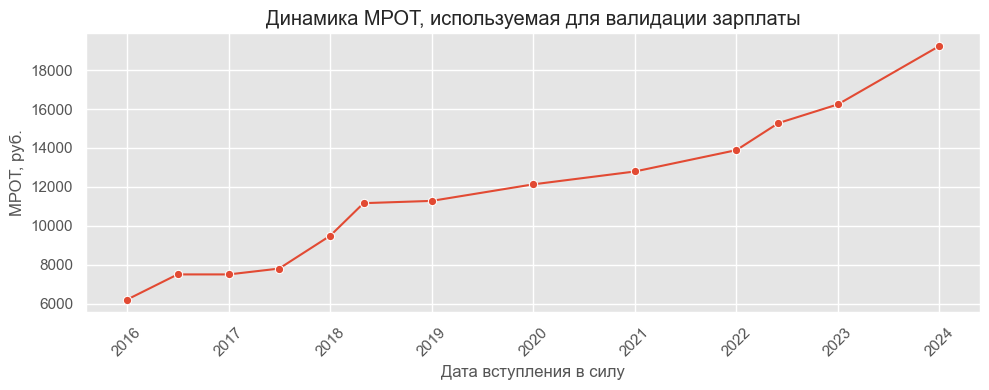

,effective_date,mrot
0,2016-01-01,6204
1,2016-07-01,7500
2,2017-01-01,7500
3,2017-07-01,7800
4,2018-01-01,9489
5,2018-05-01,11163
6,2019-01-01,11280
7,2020-01-01,12130
8,2021-01-01,12792
9,2022-01-01,13890


In [54]:
mrot_df = pd.DataFrame(mrot_schedule, columns=["effective_date", "mrot"])
plt.style.use("ggplot")
plt.figure(figsize=(10, 4))
sns.lineplot(data=mrot_df, x="effective_date", y="mrot", marker="o")
plt.title("Динамика МРОТ, используемая для валидации зарплаты")
plt.xlabel("Дата вступления в силу")
plt.ylabel("МРОТ, руб.")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

mrot_df

## 5. Очистка данных и создание `clean_df`

In [55]:
clean_df = df.copy()

rows_before = len(clean_df)

# 1. Полные дубли
full_dups_removed = int(clean_df.duplicated().sum())
clean_df = clean_df.drop_duplicates().copy()

# 2. Сохраняем последнюю доступную версию резюме по id_cv
clean_df = clean_df.sort_values(
    ["id_cv", "date_publish", "date_modify_inner_info", "date_last_updated"],
    ascending=[True, True, True, True],
    na_position="last",
).copy()
duplicated_cv_removed = int(clean_df.duplicated(subset=["id_cv"], keep="last").sum())
clean_df = clean_df.drop_duplicates(subset=["id_cv"], keep="last").copy()

# 3. Удаляем строки с явно некорректной зарплатой
invalid_salary_removed = int((~clean_df["salary_valid"]).sum())
clean_df = clean_df[clean_df["salary_valid"]].copy()

# 4. Удаляем строки с явно некорректным опытом
invalid_experience_removed = int((~clean_df["experience_valid"]).sum())
clean_df = clean_df[clean_df["experience_valid"]].copy()

# 5. Удаляем водительские позиции без водительских прав
driver_without_licence_mask = clean_df["is_driver_role"] & (~clean_df["has_any_driver_licence"])
driver_without_licence_removed = int(driver_without_licence_mask.sum())
clean_df = clean_df[~driver_without_licence_mask].copy()

rows_after = len(clean_df)
rows_removed_total = rows_before - rows_after

cleaning_summary = pd.Series({
    "rows_before": rows_before,
    "full_dups_removed": full_dups_removed,
    "duplicated_cv_removed": duplicated_cv_removed,
    "invalid_salary_removed": invalid_salary_removed,
    "invalid_experience_removed": invalid_experience_removed,
    "driver_without_licence_removed": driver_without_licence_removed,
    "rows_after": rows_after,
    "rows_removed_total": rows_removed_total,
})

cleaning_summary

rows_before                       49999
full_dups_removed                     0
duplicated_cv_removed              4251
invalid_salary_removed             2134
invalid_experience_removed           95
driver_without_licence_removed      292
rows_after                        43227
rows_removed_total                 6772
dtype: int64

## 6. Проверка правила для водителей

In [56]:
driver_rows_before = df[df["is_driver_role"]].copy()
driver_rows_after = clean_df[clean_df["is_driver_role"]].copy()

print("driver rows before:", len(driver_rows_before))
print("driver rows after:", len(driver_rows_after))

display(driver_rows_before[["position_name", "has_any_driver_licence"]].value_counts().head(20))
display(driver_rows_after[["position_name", "has_any_driver_licence"]].value_counts().head(20))

driver rows before: 1403
driver rows after: 960


position_name                  has_any_driver_licence
Водитель                       True                      307
Водитель автомобиля            True                      209
Водитель                       False                     125
Водитель погрузчика            True                       49
Водитель автомобиля            False                      45
Водитель погрузчика            False                      29
Водитель категории в           True                       21
Водитель-экспедитор            True                       14
Персональный водитель          True                        8
Водитель экспедитор            True                        7
Водитель легкового автомобиля  True                        6
Водитель автобуса              True                        5
Водитель категории c           False                       5
Водитель автопогрузчика        True                        5
Водитель категории в           False                       5
Водитель категории в, с        

position_name                  has_any_driver_licence
Водитель                       True                      278
Водитель автомобиля            True                      187
Водитель погрузчика            True                       44
Водитель категории в           True                       16
Водитель-экспедитор            True                       14
Персональный водитель          True                        8
Водитель экспедитор            True                        7
Водитель категории в, с        True                        5
Водитель автобуса              True                        5
Водитель кат. в                True                        4
Личный водитель                True                        4
Водитель легкового автомобиля  True                        4
Водитель категории в с         True                        3
Водитель категории в,с         True                        3
Водитель автопогрузчика        True                        3
Водитель вездехода             

## 7. Профиль `clean_df`

In [57]:
clean_summary = {
    "rows": len(clean_df),
    "columns": clean_df.shape[1],
    "duplicated_id_cv": int(clean_df["id_cv"].duplicated().sum()),
    "duplicated_id_candidate": int(clean_df["id_candidate"].duplicated().sum()),
}
clean_summary

{'rows': 43227,
 'columns': 66,
 'duplicated_id_cv': 0,
 'duplicated_id_candidate': 3639}

In [58]:
(clean_df.isna().mean() * 100).sort_values(ascending=False).head(15).round(2)

worldskills_international_name    99.92
worldskills_skill_abbreviation    99.88
worldskills_is_international      99.88
worldskills_russian_name          99.88
nark_certificate                  99.79
worldskills_type                  99.78
add_certificates                  92.44
other_info                        86.18
education_type                    79.16
birthday                          74.87
birthday_mistake                  73.36
drive_licences                    63.54
profession_code                   52.68
skills                            50.24
additional_skills                 37.19
dtype: float64

In [59]:
clean_df[[
    "id_cv",
    "id_candidate",
    "position_name",
    "salary",
    "experience",
    "region_name",
    "region_group",
    "has_any_driver_licence",
    "is_driver_role",
]].head(10)

,id_cv,id_candidate,position_name,salary,experience,region_name,region_group,has_any_driver_licence,is_driver_role
28263,0000fa80-f485-11e5-b72a-037acc02728d,7d5f6b60-88e2-11e5-a923-239645b044d5,Оператор,20000,17.0,Еврейская автономная область,Дальний Восток|Горнодобывающие,False,False
47312,00021f88-5142-11e7-8cfa-736ab11edb0c,e95184c0-5140-11e7-8cfa-736ab11edb0c,Продавец,20000,0.0,Москва,Столицы|Центральная Россия,False,False
41130,00023619-9edf-11e7-98d5-736ab11edb0c,bdb304c0-9ed8-11e7-98d5-736ab11edb0c,Бухгалтер,25000,12.0,Коми,Промышленные центры|Северо-Запад|Горнодобывающие,False,False
36577,00039860-a657-11e6-8c55-037acc02728d,a19abdd0-a656-11e6-8c55-037acc02728d,Водитель погрузчика,30000,0.0,Хакасия,Дальний Восток|Горнодобывающие,True,True
8672,00049280-724d-11eb-b1cf-b905beff6f7a,74975780-70e1-11eb-9893-7bf9d8e248ac,Водитель категории в с,35000,3.0,Красноярский край,Промышленные центры|Сибирь|Горнодобывающие,True,True
10061,0006beab-6894-11e7-b987-ef76bd2a03c1,726ad900-67c6-11e7-92fe-037acc02728d,"Инженер (в строительстве, жкх)",20000,6.0,Челябинская область,Промышленные центры|Урал|Горнодобывающие,False,False
16089,0007a7f0-6cdf-11ea-85aa-ef76bd2a03c1,b17c14e0-6cde-11ea-85aa-ef76bd2a03c1,Уборщик производственных и служебных помещений,15000,0.0,Смоленская область,Центральная Россия|Промышленные центры,False,False
10959,0007d7e0-fe68-11eb-bb83-ab5d2eb93a75,37e2df50-fc3a-11eb-9016-7bf9d8e248ac,Администратор,30000,0.0,Марий Эл,Промышленные центры|Поволжье,False,False
15681,000ac230-7af6-11ea-b2a7-736ab11edb0c,8b85d6a0-7af2-11ea-b2a7-736ab11edb0c,Строительство,60000,10.0,Приморский край,Дальний Восток|Горнодобывающие,True,False
19715,000b7ad0-2dab-11e8-b956-037acc02728d,0386de10-0a4d-11e8-8956-037acc02728d,Помощник,15000,24.0,Чеченская Республика,Южные регионы|Сельские регионы|Северный Кавказ,False,False


## 8. Быстрые визуальные проверки

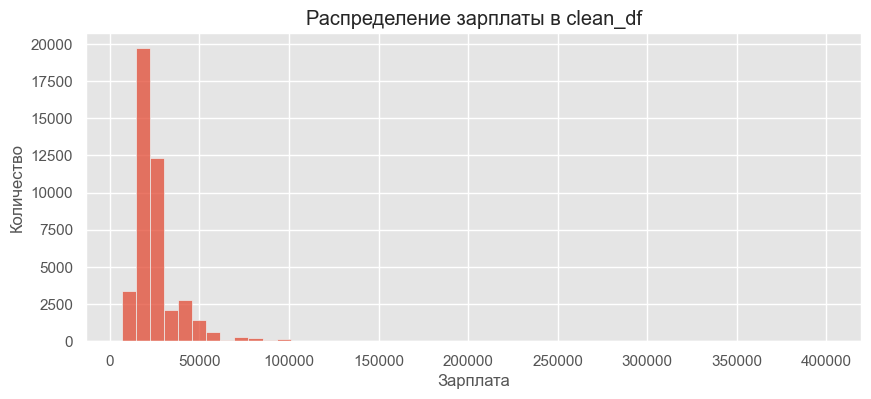

In [60]:
plt.figure(figsize=(10, 4))
sns.histplot(clean_df["salary"].dropna(), bins=50)
plt.title("Распределение зарплаты в clean_df")
plt.xlabel("Зарплата")
plt.ylabel("Количество")
plt.show()

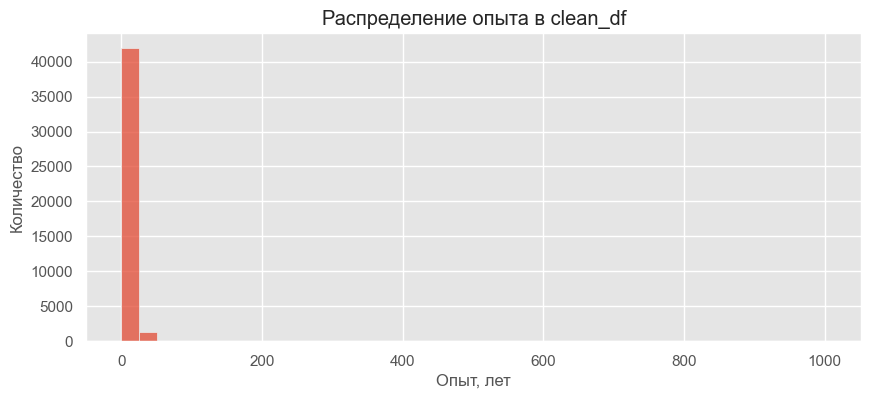

In [61]:
plt.figure(figsize=(10, 4))
sns.histplot(clean_df["experience"].dropna(), bins=40)
plt.title("Распределение опыта в clean_df")
plt.xlabel("Опыт, лет")
plt.ylabel("Количество")
plt.show()

## 9. Сохранение чистого датафрейма

In [62]:
clean_df.to_csv("dataset_cleaned.csv", index=False)
print("saved to dataset_cleaned.csv")

saved to dataset_cleaned.csv


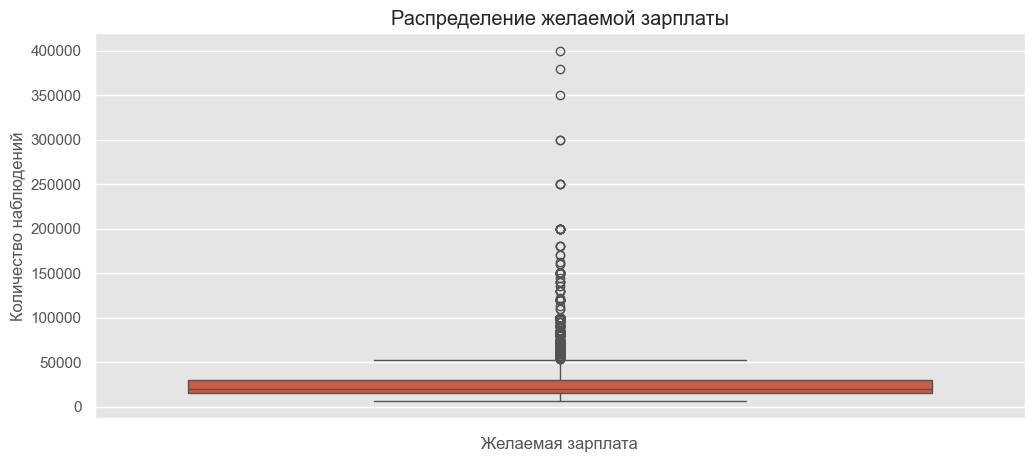

In [63]:
plt.figure(figsize=(12, 5))
sns.boxplot(clean_df["salary"].dropna())
plt.title("Распределение желаемой зарплаты")
plt.xlabel("Желаемая зарплата")
plt.ylabel("Количество наблюдений")
plt.show()

In [64]:
clean_df.head()

,add_certificates,additional_skills,birthday,birthday_mistake,business_trips,busy_type,country,date_creation,date_inactivation,date_last_updated,date_modify_inner_info,date_publish,date_time_publish,drive_licences,driver_licence_a,driver_licence_b,driver_licence_c,driver_licence_d,driver_licence_e,education_type,experience,experience_mistake,gender,id_candidate,id_cv,id_user_inner_info,inactive,industry_code,inner_info_fullness_rate,inner_info_status,locality,nark_certificate,other_info,position_name,profession_code,region_code,relocation,retraining_capability,salary,schedule_type,schedule_type_1,schedule_type_2,schedule_type_3,schedule_type_4,schedule_type_5,schedule_type_6,skills,time_publish,worldskills_international_name,worldskills_is_international,worldskills_russian_name,worldskills_skill_abbreviation,worldskills_type,worldskills_inspection_status,position_name_norm,has_any_driver_licence,is_driver_role,salary_floor_mrot,salary_valid,experience_valid,region_prefix,code,region_group,region_name,federal_district,region_primary_group
28263,NaN,"Ответственная, пунктуальная, коммуникабельная,...",NaN,NaN,0.0,Полная занятость,Российская Федерация,2016-10-19,2019-04-10,2019-02-18,2019-01-10,2016-10-19,2016-10-19 06:59:26,NaN,0,0,0,0,0,NaN,17.0,0,Женский,7d5f6b60-88e2-11e5-a923-239645b044d5,0000fa80-f485-11e5-b72a-037acc02728d,47e148d0-054f-11e5-88ed-1ff705945672,1,Finances,88,Одобрено,7.900000e+12,NaN,NaN,Оператор,203369.0,7.900000e+12,0.0,1.0,20000,Полный рабочий день,0,0,0,0,1,0,"Уверенный пользователь ПК, знание программ: 1С...",06:59:26,NaN,NaN,NaN,NaN,NaN,Не применимо,оператор,False,False,7500.0,True,True,79,79,Дальний Восток|Горнодобывающие,Еврейская автономная область,Дальневосточный,Дальний Восток
47312,NaN,NaN,NaN,NaN,0.0,Частичная занятость,Российская Федерация,2017-06-14,2019-04-10,2019-02-18,2018-08-10,2017-06-15,2017-06-15 06:17:52,NaN,0,0,0,0,0,NaN,0.0,0,Женский,e95184c0-5140-11e7-8cfa-736ab11edb0c,00021f88-5142-11e7-8cfa-736ab11edb0c,fd002330-9c20-11e6-b209-5d9e90ab9534,1,Sales,59,Одобрено,7.700000e+12,NaN,NaN,Продавец,NaN,7.700000e+12,0.0,1.0,20000,"Гибкий график,Полный рабочий день,Неполный раб...",0,1,0,1,1,1,NaN,06:17:52,NaN,NaN,NaN,NaN,NaN,Не применимо,продавец,False,False,7500.0,True,True,77,77,Столицы|Центральная Россия,Москва,Центральный,Столицы
41130,NaN,Веду здоровый образ жизни!,NaN,NaN,0.0,Полная занятость,Российская Федерация,2017-09-21,2019-04-10,2019-02-18,2018-05-01,2018-05-01,2018-05-01 07:03:18,NaN,0,0,0,0,0,NaN,12.0,0,Женский,bdb304c0-9ed8-11e7-98d5-736ab11edb0c,00023619-9edf-11e7-98d5-736ab11edb0c,9bfd4780-202e-11e5-8442-1ff705945672,1,Finances,77,Одобрено,1.100001e+12,NaN,Владение компьютером: на уровне опытного польз...,Бухгалтер,NaN,1.100000e+12,0.0,1.0,25000,Полный рабочий день,0,0,0,0,1,0,"Коммуникабельная, ответственная, аккуратная, и...",07:03:18,NaN,NaN,NaN,NaN,NaN,Не применимо,бухгалтер,False,False,11163.0,True,True,11,11,Промышленные центры|Северо-Запад|Горнодобывающие,Коми,Северо-Западный,Промышленные центры
36577,NaN,NaN,NaN,NaN,0.0,Полная занятость,Российская Федерация,2016-11-09,2019-04-10,2019-02-18,2018-07-26,2016-11-09,2016-11-09 11:41:56,"[B, C]",0,1,1,0,0,NaN,0.0,0,Мужской,a19abdd0-a656-11e6-8c55-037acc02728d,00039860-a657-11e6-8c55-037acc02728d,f85d5660-02b9-11e5-85f7-1ff705945672,1,Resources,49,Одобрено,1.900200e+12,NaN,NaN,Водитель погрузчика,114536.0,1.900000e+12,0.0,1.0,30000,"Гибкий график,Полный рабочий день,Ненормирован...",1,1,1,1,1,1,NaN,11:41:56,NaN,NaN,NaN,NaN,NaN,Не применимо,водитель погрузчика,True,True,7500.0,True,True,19,19,Дальний Восток|Горнодобывающие,Хакасия,Сибирский,Дальний Восток
8672,NaN,"Комуникабельный, без вредных превычек",1980.0,0.0,1.0,Полная занятость,Российская Федерация,2021-02-19,NaT,2021-02-26,2021-02-19,2021-02-19,2021-02-19 04:42:10,"[B, C]",0,1,1,0,0,Среднее,3.0,0,Мужской,74975780-70e1-11eb-9893-7bf9d8e248ac,00049280-724d-11eb-b1cf-b905beff6f7a,47780b10-02af-11e5-85f7-1ff705945672,0,Transport,69,Одобрено,2.400000e+12,NaN,NaN,Водитель к

## 10. Итог

In [65]:
cleaning_summary_ru = cleaning_summary.rename({
    "rows_before": "Строк до очистки",
    "full_dups_removed": "Удалено полных дублей",
    "duplicated_cv_removed": "Удалено дублей по id_cv",
    "invalid_salary_removed": "Удалено строк с некорректной зарплатой",
    "invalid_experience_removed": "Удалено строк с некорректным опытом",
    "driver_without_licence_removed": "Удалено водительских резюме без прав",
    "rows_after": "Строк после очистки",
    "rows_removed_total": "Всего удалено строк",
}).astype(int)

cleaning_summary_ru

Строк до очистки                          49999
Удалено полных дублей                         0
Удалено дублей по id_cv                    4251
Удалено строк с некорректной зарплатой     2134
Удалено строк с некорректным опытом          95
Удалено водительских резюме без прав        292
Строк после очистки                       43227
Всего удалено строк                        6772
dtype: int64

In [66]:
cleaning_share_removed = rows_removed_total / rows_before * 100

print(f"Доля удалённых строк: {cleaning_share_removed:.2f}%")
print(f"Итоговый размер clean_df: {clean_df.shape[0]} строк и {clean_df.shape[1]} столбцов")

Доля удалённых строк: 13.54%
Итоговый размер clean_df: 43227 строк и 66 столбцов


После выполнения ноутбука получается `clean_df` и файл `dataset_cleaned.csv`.

Основные итоги очистки:
- удалены полные дубли строк;
- для повторяющихся `id_cv` оставлена последняя доступная версия резюме;
- исключены строки с явно некорректной зарплатой и опытом;
- удалены водительские резюме без указанных водительских прав.

В результате сформирована воспроизводимая базовая очищенная выборка, подходящая для дальнейшего EDA, проверки гипотез и построения моделей.